In [1]:
import sys
import os

sys.path.append(os.path.abspath('..'))  

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt



In [3]:
%load_ext autoreload
%autoreload 2

In [4]:
from src.preprocess.basic import (
    basic_preprocess_train,
    basic_preprocess_test,
    load_raw,
    drop_low_variance,
    add_rul
)

In [5]:
# run preprocessing on training data
project_root = '/Users/lohitha/Documents/Lohitha Drexel/Predictive Maintainance'

df_train_clean = basic_preprocess_train(
    file_name=os.path.join(project_root, "data/raw/train_FD001.txt"),
    variance_threshold=0.001,
    max_rul=130,
    save_path=os.path.join(project_root, "data/processed/train_clean.csv")
)

df_train_clean.head()

(20631, 26)
dropping: ['setting_2', 'setting_3', 'sensor_1', 'sensor_5', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19']
saved to /Users/lohitha/Documents/Lohitha Drexel/Predictive Maintainance/data/processed/train_clean.csv


,engine_number,cycle,setting_1,sensor_2,sensor_3,sensor_4,sensor_6,sensor_7,sensor_8,sensor_9,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_17,sensor_20,sensor_21,RUL_capped
0,1,1,-0.0007,641.82,1589.70,1400.60,21.61,554.36,2388.06,9046.19,47.47,521.66,2388.02,8138.62,8.4195,392,39.06,23.4190,130
1,1,2,0.0019,642.15,1591.82,1403.14,21.61,553.75,2388.04,9044.07,47.49,522.28,2388.07,8131.49,8.4318,392,39.00,23.4236,130
2,1,3,-0.0043,642.35,1587.99,1404.20,21.61,554.26,2388.08,9052.94,47.27,522.42,2388.03,8133.23,8.4178,390,38.95,23.3442,130
3,1,4,0.0007,642.35,1582.79,1401.87,21.61,554.45,2388.11,9049.48,47.13,522.86,2388.08,8133.83,8.3682,392,38.88,23.3739,130
4,1,5,-0.0019,642.37,1582.85,1406.22,21.61,554.00,2388.06,9055.15,47.28,522.19,2388.04,8133.80,8.4294,393,38.90,23.4044,130


In [6]:
print(df_train_clean.shape)
print(df_train_clean.columns.tolist())
df_train_clean.tail()
df_train_clean.dtypes

(20631, 19)
['engine_number', 'cycle', 'setting_1', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21', 'RUL_capped']


engine_number      int64
cycle              int64
setting_1        float64
sensor_2         float64
sensor_3         float64
sensor_4         float64
sensor_6         float64
sensor_7         float64
sensor_8         float64
sensor_9         float64
sensor_11        float64
sensor_12        float64
sensor_13        float64
sensor_14        float64
sensor_15        float64
sensor_17          int64
sensor_20        float64
sensor_21        float64
RUL_capped         int64
dtype: object

In [7]:
engine_id = 1
engine_data = df_train_clean[df_train_clean['engine_number'] == engine_id]
engine_data[['cycle', 'RUL_capped']].head(10)

,cycle,RUL_capped
0,1,130
1,2,130
2,3,130
3,4,130
4,5,130
5,6,130
6,7,130
7,8,130
8,9,130
9,10,130


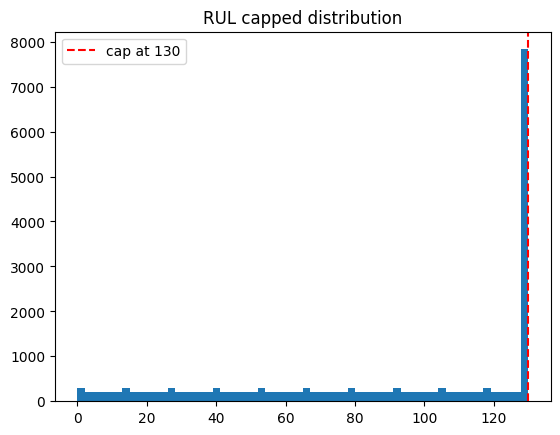

37.0% of rows hit the cap


In [8]:
#what does the RUL distribution look like after capping?
plt.hist(df_train_clean['RUL_capped'], bins=60)
plt.axvline(130, color='red', linestyle='--', label='cap at 130')
plt.legend()
plt.title('RUL capped distribution')
plt.show()

capped_count = (df_train_clean['RUL_capped'] == 130).sum()
print(f"{capped_count / len(df_train_clean) * 100:.1f}% of rows hit the cap")

In [9]:
# check remaining sensors
remaining_sensors = [col for col in df_train_clean.columns if 'sensor' in col]
print(len(remaining_sensors), "sensors remaining")
print(remaining_sensors)

15 sensors remaining
['sensor_2', 'sensor_3', 'sensor_4', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21']


In [10]:
# preprocess test data too
df_test_clean = basic_preprocess_test(
    file_name=os.path.join(project_root, "data/raw/test_FD001.txt"),
    variance_threshold=0.001,
    save_path=os.path.join(project_root, "data/processed/test_clean.csv")
)

df_test_clean.head()

(13096, 26)
dropping: ['setting_2', 'setting_3', 'sensor_1', 'sensor_5', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19']


,engine_number,cycle,setting_1,sensor_2,sensor_3,sensor_4,sensor_6,sensor_7,sensor_8,sensor_9,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_17,sensor_20,sensor_21
0,1,1,0.0023,643.02,1585.29,1398.21,21.61,553.90,2388.04,9050.17,47.20,521.72,2388.03,8125.55,8.4052,392,38.86,23.3735
1,1,2,-0.0027,641.71,1588.45,1395.42,21.61,554.85,2388.01,9054.42,47.50,522.16,2388.06,8139.62,8.3803,393,39.02,23.3916
2,1,3,0.0003,642.46,1586.94,1401.34,21.61,554.11,2388.05,9056.96,47.50,521.97,2388.03,8130.10,8.4441,393,39.08,23.4166
3,1,4,0.0042,642.44,1584.12,1406.42,21.61,554.07,2388.03,9045.29,47.28,521.38,2388.05,8132.90,8.3917,391,39.00,23.3737
4,1,5,0.0014,642.51,1587.19,1401.92,21.61,554.16,2388.01,9044.55,47.31,522.15,2388.03,8129.54,8.4031,390,38.99,23.4130


In [11]:
print(df_test_clean.shape)
df_test_clean.head()

(13096, 18)


,engine_number,cycle,setting_1,sensor_2,sensor_3,sensor_4,sensor_6,sensor_7,sensor_8,sensor_9,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_17,sensor_20,sensor_21
0,1,1,0.0023,643.02,1585.29,1398.21,21.61,553.90,2388.04,9050.17,47.20,521.72,2388.03,8125.55,8.4052,392,38.86,23.3735
1,1,2,-0.0027,641.71,1588.45,1395.42,21.61,554.85,2388.01,9054.42,47.50,522.16,2388.06,8139.62,8.3803,393,39.02,23.3916
2,1,3,0.0003,642.46,1586.94,1401.34,21.61,554.11,2388.05,9056.96,47.50,521.97,2388.03,8130.10,8.4441,393,39.08,23.4166
3,1,4,0.0042,642.44,1584.12,1406.42,21.61,554.07,2388.03,9045.29,47.28,521.38,2388.05,8132.90,8.3917,391,39.00,23.3737
4,1,5,0.0014,642.51,1587.19,1401.92,21.61,554.16,2388.01,9044.55,47.31,522.15,2388.03,8129.54,8.4031,390,38.99,23.4130


In [12]:
df_test_clean.groupby('engine_number')['cycle'].max().describe()


count    100.000000
mean     130.960000
std       53.593479
min       31.000000
25%       88.750000
50%      133.500000
75%      164.250000
max      303.000000
Name: cycle, dtype: float64

In [13]:
#make sure train and test have same columns
train_cols = [col for col in df_train_clean.columns if col not in ['engine_number', 'cycle', 'RUL_capped']]
test_cols = [col for col in df_test_clean.columns if col not in ['engine_number', 'cycle']]

print(train_cols)
print(test_cols)
print(train_cols == test_cols)

['setting_1', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21']
['setting_1', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21']
True


In [14]:
#do train and test look similar?
sensors_to_compare = ['sensor_2', 'sensor_7', 'sensor_11', 'sensor_14']

df_train_clean[sensors_to_compare].describe()

,sensor_2,sensor_7,sensor_11,sensor_14
count,20631.000000,20631.000000,20631.000000,20631.000000
mean,642.680934,553.367711,47.541168,8143.752722
std,0.500053,0.885092,0.267087,19.076176
min,641.210000,549.850000,46.850000,8099.940000
25%,642.325000,552.810000,47.350000,8133.245000
50%,642.640000,553.440000,47.510000,8140.540000
75%,643.000000,554.010000,47.700000,8148.310000
max,644.530000,556.060000,48.530000,8293.720000


In [15]:
df_test_clean[sensors_to_compare].describe()

,sensor_2,sensor_7,sensor_11,sensor_14
count,13096.000000,13096.000000,13096.000000,13096.000000
mean,642.475088,553.757523,47.416204,8138.947817
std,0.400899,0.681286,0.195917,10.188605
min,641.130000,550.880000,46.800000,8108.500000
25%,642.197500,553.310000,47.270000,8132.310000
50%,642.460000,553.800000,47.410000,8138.390000
75%,642.740000,554.240000,47.540000,8144.360000
max,644.300000,555.840000,48.260000,8220.480000


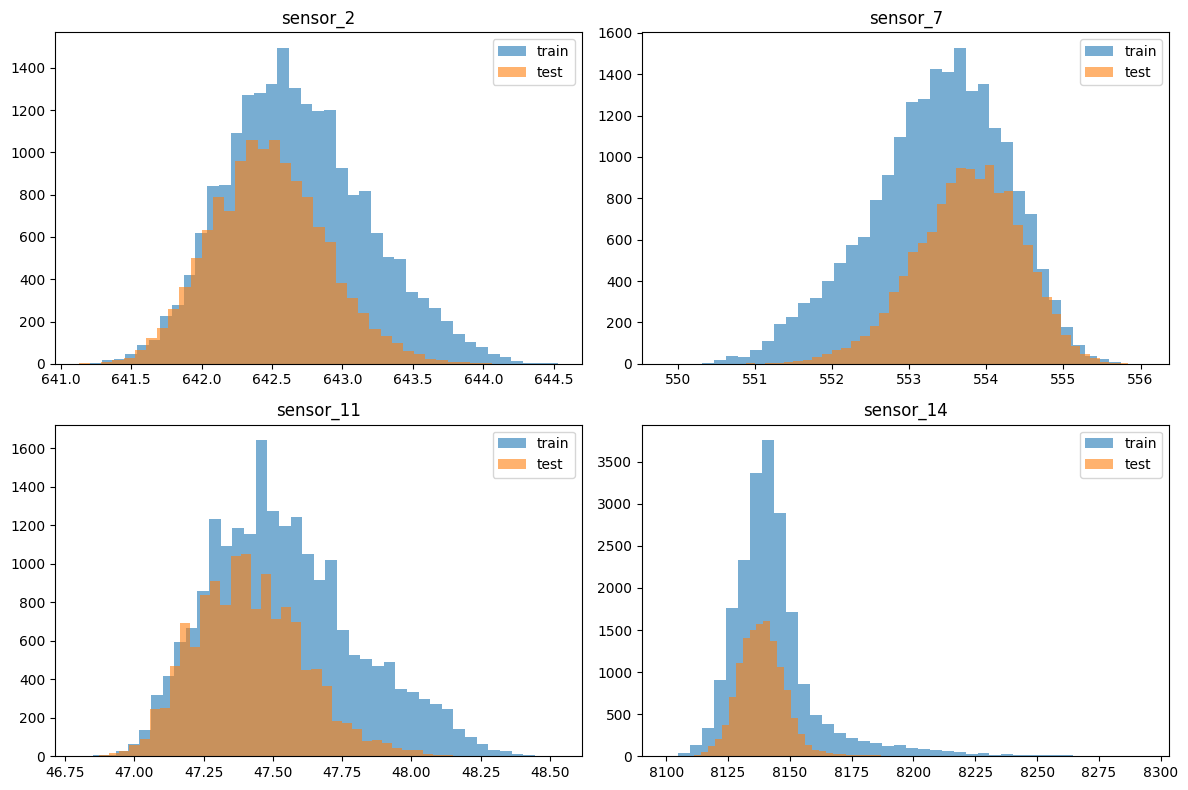

In [16]:
#do train and test distributions look similar?
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()

for i, sensor in enumerate(['sensor_2', 'sensor_7', 'sensor_11', 'sensor_14']):
    axes[i].hist(df_train_clean[sensor], bins=40, alpha=0.6, label='train')
    axes[i].hist(df_test_clean[sensor], bins=40, alpha=0.6, label='test')
    axes[i].set_title(sensor)
    axes[i].legend()

plt.tight_layout()
plt.show()
# looks pretty similar

## notes

- dropped 8 constant sensors, 17 features remaining
- RUL capped at 130, about 36% of rows hit the cap
- train and test distributions look similar enough
- next: feature engineering